In [1]:
%load_ext autoreload
%autoreload 2

In [41]:
import planetary_computer as pc
from pystac_client import Client
import pandas as pd
import numpy as np
import geopy.distance as distance
from datetime import timedelta
from time import time
import matplotlib.pyplot as plt

import rioxarray
from IPython.display import Image
from PIL import Image as PILImage

from pyproj import Transformer


In [3]:

def get_bounding_box(latitude, longitude, meter_buffer=50000):
    """
    Given a latitude, longitude, and buffer in meters, returns a bounding
    box around the point with the buffer on the left, right, top, and bottom.

    Returns a list of [minx, miny, maxx, maxy]
    """
    distance_search = distance.distance(meters=meter_buffer)

    # calculate the lat/long bounds based on ground distance
    # bearings are cardinal directions to move (south, west, north, and east)
    min_lat = distance_search.destination((latitude, longitude), bearing=180)[0]
    min_long = distance_search.destination((latitude, longitude), bearing=270)[1]
    max_lat = distance_search.destination((latitude, longitude), bearing=0)[0]
    max_long = distance_search.destination((latitude, longitude), bearing=90)[1]

    return [min_long, min_lat, max_long, max_lat]



In [4]:

def get_date_range(date, time_buffer_days=15):
    """Get a date range to search for in the planetary computer based
    on a sample's date. The time range will include the sample date
    and time_buffer_days days prior

    Returns a string"""
    datetime_format = "%Y-%m-%d"
    range_start = pd.to_datetime(date) - timedelta(days=time_buffer_days)
    range_end = pd.to_datetime(date) + timedelta(days=time_buffer_days)
    date_range = f"{range_start.strftime(datetime_format)}/{range_end.strftime(datetime_format)}"

    return date_range



In [5]:
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1", modifier=pc.sign_inplace
)


In [25]:
df = pd.read_excel(r"C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\IWD\tick tick bloom data\junk4.xlsx")
high_sev = df[(df.severity > 3)&(df.date >= "2017-01-01")]

In [26]:
high_sev.cluster_size.value_counts().sort_index(ascending=False)

cluster_size
37       1
26      13
22       1
21       4
20       4
18       8
16       6
15       1
14       1
13       6
12       2
11       3
10      16
9        2
8        5
7       15
6       34
5       37
4      119
3      100
2      437
1     2580
Name: count, dtype: int64

In [27]:
high_sev[high_sev.cluster_size == 26]

,uid,data_provider,region,lat,lon,date,time,year,month,day,abun,severity,distance_to_water_m,cyfi class,case,case_str,cluster_size
2277,cedy,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.078680,-96.886523,2019-09-04,0:01:00,2019,9,4,1626.975,4,0.0,High,1858,1858,26
2278,cnsz,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-10-07,0:01:00,2019,10,7,1197.000,4,0.0,High,1858,"1858 , 1858 , 1858",26
2285,difw,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.078680,-96.886523,2019-08-12,0:01:00,2019,8,12,1020.600,4,0.0,High,1858,"1858 , 1858",26
2292,fjjk,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-09-04,0:01:00,2019,9,4,1409.625,4,0.0,High,1858,1858,26
2302,gkdu,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.078680,-96.886523,2019-07-15,0:01:00,2019,7,15,1045.800,4,0.0,High,1858,"1858 , 1858",26
2303,gmhy,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-09-23,0:01:00,2019,9,23,1339.380,4,0.0,High,1858,"1858 , 1858 , 1858",26
2322,kict,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-07-29,0:01:00,2019,7,29,1030.680,4,0.0,High,1858,"1858 , 1858 , 1858 , 1858",26
2335,myfe,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.078680,-96.886523,2019-08-19,0:01:00,2019,8,19,1292.130,4,0.0,High,1858,"1858 , 1858 , 1858",26
2344,oots,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-08-19,0:01:00,2019,8,19,4528.125,4,0.0,High,1858,"1858 , 1858 , 1858",26
2380,swim,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-07-15,0:01:00,2019,7,15,1251.810,4,0.0,High,1858,"1858 , 1858",26


In [28]:
d1 = high_sev[high_sev.case == 1858]
d1

,uid,data_provider,region,lat,lon,date,time,year,month,day,abun,severity,distance_to_water_m,cyfi class,case,case_str,cluster_size
2277,cedy,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.078680,-96.886523,2019-09-04,0:01:00,2019,9,4,1626.975,4,0.0,High,1858,1858,26
2278,cnsz,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-10-07,0:01:00,2019,10,7,1197.000,4,0.0,High,1858,"1858 , 1858 , 1858",26
2285,difw,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.078680,-96.886523,2019-08-12,0:01:00,2019,8,12,1020.600,4,0.0,High,1858,"1858 , 1858",26
2292,fjjk,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-09-04,0:01:00,2019,9,4,1409.625,4,0.0,High,1858,1858,26
2302,gkdu,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.078680,-96.886523,2019-07-15,0:01:00,2019,7,15,1045.800,4,0.0,High,1858,"1858 , 1858",26
2303,gmhy,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-09-23,0:01:00,2019,9,23,1339.380,4,0.0,High,1858,"1858 , 1858 , 1858",26
2322,kict,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-07-29,0:01:00,2019,7,29,1030.680,4,0.0,High,1858,"1858 , 1858 , 1858 , 1858",26
2335,myfe,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.078680,-96.886523,2019-08-19,0:01:00,2019,8,19,1292.130,4,0.0,High,1858,"1858 , 1858 , 1858",26
2344,oots,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-08-19,0:01:00,2019,8,19,4528.125,4,0.0,High,1858,"1858 , 1858 , 1858",26
2380,swim,Bureau_of_Water_Kansas_Department_of_Health_an...,midwest,39.077955,-96.880810,2019-07-15,0:01:00,2019,7,15,1251.810,4,0.0,High,1858,"1858 , 1858",26


In [30]:
d1.date.value_counts().sort_index(ascending=False)

date
2019-10-07    1
2019-09-23    1
2019-09-04    2
2019-08-26    1
2019-08-19    2
2019-08-12    1
2019-08-05    1
2019-07-29    1
2019-07-15    2
2019-06-24    1
Name: count, dtype: int64

In [31]:
test_dates = d1[d1.date == "2019-08-19"]
print(test_dates.shape)
p_lon = np.mean([min(test_dates.lon),max(test_dates.lon)])
p_lat = np.mean([min(test_dates.lat),max(test_dates.lat)])
print(p_lon, p_lat, set(test_dates.date))


(2, 17)
-96.8836665 39.0783175 {Timestamp('2019-08-19 00:00:00')}


In [32]:

bbox = get_bounding_box(p_lat, p_lon, meter_buffer=3000)
print(bbox)


[-96.91833622427428, 39.05129454297629, -96.84899677572572, 39.10534033143383]


In [33]:

date_range = get_date_range(test_dates.date.iloc[0])
date_range


'2019-08-04/2019-09-03'

In [34]:

search = catalog.search(
    collections=["sentinel-2-l2a"], bbox=bbox, datetime=date_range
)


In [35]:

t1 = time()
items = [item for item in search.get_all_items()]
t2 = time()
len(items)



C:\Users\KostasPikounis\anaconda3\envs\AMFITRITE\lib\site-packages\pystac_client\item_search.py:940: FutureWarning: get_all_items() is deprecated, use item_collection() instead.
  warnings.warn(


6

In [36]:

item_details = pd.DataFrame(
    [
        {
            "datetime": item.datetime.strftime("%Y-%m-%d"),
            "platform": item.properties["platform"],
            "min_long": item.bbox[0],
            "max_long": item.bbox[2],
            "min_lat": item.bbox[1],
            "max_lat": item.bbox[3],
            "bbox": item.bbox,
            "item_obj": item,
        }
        for item in items
    ]
)

# check which rows actually contain the sample location
item_details["contains_sample_point"] = (
    (item_details.min_lat < p_lat)
    & (item_details.max_lat > p_lat)
    & (item_details.min_long < p_lon)
    & (item_details.max_long > p_lon)
)

print(
    f"Filtering from {len(item_details)} returned to {item_details.contains_sample_point.sum()} items that contain the sample location"
)

item_details = item_details[item_details["contains_sample_point"]]
item_details[["datetime", "platform", "contains_sample_point", "bbox"]].sort_values(
    by="datetime"
)

item_details["per_clouds"] = -1


Filtering from 6 returned to 6 items that contain the sample location


In [37]:
for it, row in item_details.iterrows():
    ar = rioxarray.open_rasterio(pc.sign(row.item_obj.assets["SCL"].href)).to_numpy()
    cloud_per = round(100*sum(ar >= 7).sum()/(ar.shape[0]*ar.shape[1]*ar.shape[2]),2)
    item_details.at[it, "per_clouds"] = cloud_per

item_details['date_difference'] = (pd.to_datetime(item_details['datetime']) - test_dates.date.iloc[0]).dt.days
item_details

C:\Users\KostasPikounis\AppData\Local\Temp\ipykernel_18252\2006908942.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.52' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  item_details.at[it, "per_clouds"] = cloud_per


,datetime,platform,min_long,max_long,min_lat,max_lat,bbox,item_obj,contains_sample_point,per_clouds,date_difference
0,2019-09-02,Sentinel-2B,-97.849128,-96.552115,38.735936,39.743725,"[-97.84912778038333, 38.73593643111066, -96.55...",<Item id=S2B_MSIL2A_20190902T170849_R112_T14SP...,True,0.52,14
1,2019-08-28,Sentinel-2A,-97.849120,-96.552124,38.735936,39.743773,"[-97.84912, 38.73593643111066, -96.552124, 39....",<Item id=S2A_MSIL2A_20190828T170851_R112_T14SP...,True,0.78,9
2,2019-08-23,Sentinel-2B,-97.849120,-96.552124,38.735936,39.743766,"[-97.84912, 38.73593643111066, -96.552124, 39....",<Item id=S2B_MSIL2A_20190823T170859_R112_T14SP...,True,80.84,4
3,2019-08-18,Sentinel-2A,-97.849120,-96.552124,38.735936,39.743795,"[-97.84912, 38.73593643111066, -96.552124, 39....",<Item id=S2A_MSIL2A_20190818T170851_R112_T14SP...,True,0.53,-1
4,2019-08-13,Sentinel-2B,-97.849120,-96.552124,38.735936,39.743782,"[-97.84912, 38.73593643111066, -96.552124, 39....",<Item id=S2B_MSIL2A_20190813T170859_R112_T14SP...,True,16.62,-6
5,2019-08-08,Sentinel-2A,-97.849120,-96.552124,38.735936,39.743805,"[-97.84912, 38.73593643111066, -96.552124, 39....",<Item id=S2A_MSIL2A_20190808T170901_R112_T14SP...,True,88.11,-11


In [13]:
### low cloud percnetage and close to date

In [38]:


item = item_details.at[3, "item_obj"]

item

<Item id=S2A_MSIL2A_20190818T170851_R112_T14SPJ_20201005T015156>

In [39]:
for asset_key, asset in item.assets.items():
    print(f"{asset_key:<25} - {asset.title}")

AOT                       - Aerosol optical thickness (AOT)
B01                       - Band 1 - Coastal aerosol - 60m
B02                       - Band 2 - Blue - 10m
B03                       - Band 3 - Green - 10m
B04                       - Band 4 - Red - 10m
B05                       - Band 5 - Vegetation red edge 1 - 20m
B06                       - Band 6 - Vegetation red edge 2 - 20m
B07                       - Band 7 - Vegetation red edge 3 - 20m
B08                       - Band 8 - NIR - 10m
B09                       - Band 9 - Water vapor - 60m
B11                       - Band 11 - SWIR (1.6) - 20m
B12                       - Band 12 - SWIR (2.2) - 20m
B8A                       - Band 8A - Vegetation red edge 4 - 20m
SCL                       - Scene classfication map (SCL)
WVP                       - Water vapour (WVP)
visual                    - True color image
preview                   - Thumbnail
safe-manifest             - SAFE manifest
granule-metadata          - Granul

In [40]:
# see the whole image
img = Image(url=item.assets["rendered_preview"].href, width=10000)
Image(url=item.assets["rendered_preview"].href, width=10000)

In [42]:
visual_href = pc.sign(item.assets["visual"].href)

In [48]:
ds = rioxarray.open_rasterio(visual_href)

bbox = get_bounding_box(p_lat, p_lon, meter_buffer=2000)

ds_clip = ds.rio.clip_box(
    minx=bbox[0], 
    miny=bbox[1], 
    maxx=bbox[2], 
    maxy=bbox[3], 
    crs="EPSG:4326" # This tells code that your bbox is in Lat/Lon
)

In [49]:
image_crs = ds_clip.rio.crs
transformer = Transformer.from_crs("EPSG:4326", image_crs, always_xy=True)

In [50]:
xx, yy = transformer.transform(test_dates.lon.values, test_dates.lat.values)

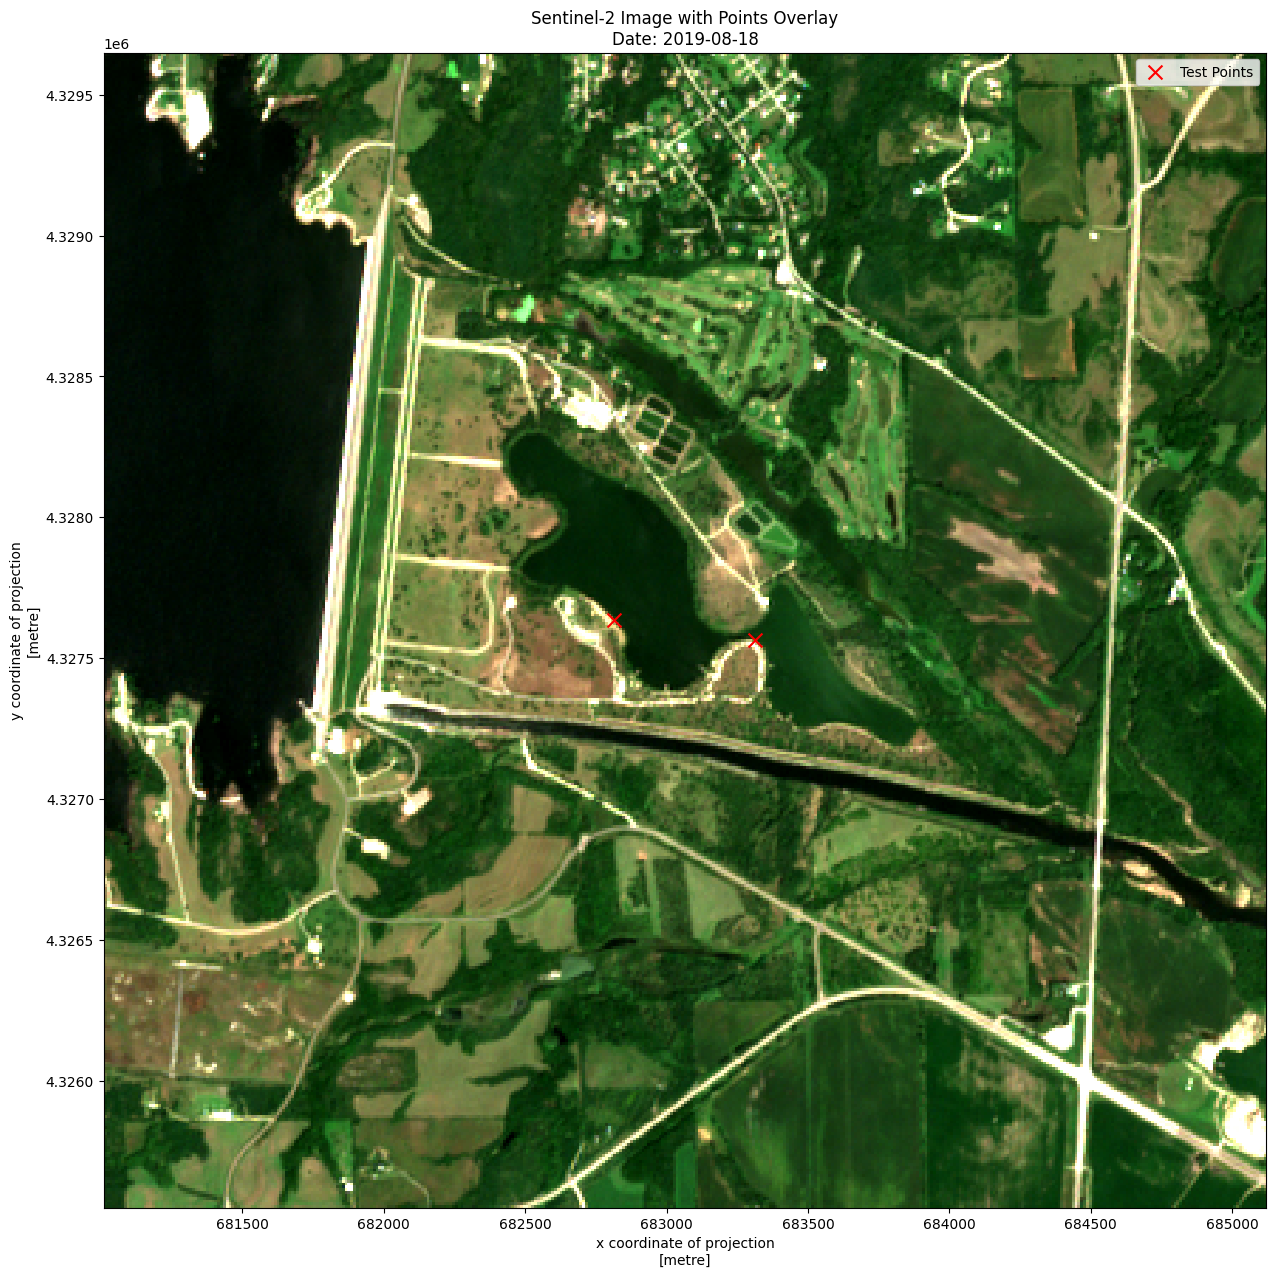

In [51]:
fig, ax = plt.subplots(figsize=(15, 15))

# Plot the satellite image
# robust=True handles color scaling so the image isn't too dark or bright
ds_clip.plot.imshow(ax=ax, rgb="band", robust=True)

# Plot the points on top
ax.scatter(xx, yy, c='red', s=100, marker='x', label='Test Points')

ax.set_title(f"Sentinel-2 Image with Points Overlay\nDate: {item.datetime.date()}")
plt.legend()
plt.show()

In [37]:
def crop_sentinel_image(item, bounding_box):
    """
    Given a STAC item from Sentinel-2 and a bounding box tuple in the format
    (minx, miny, maxx, maxy), return a cropped portion of the item's visual
    imagery in the bounding box.

    Returns the image as a numpy array with dimensions (color band, height, width)
    """
    (minx, miny, maxx, maxy) = bounding_box

    image = rioxarray.open_rasterio(pc.sign(item.assets["visual"].href)).rio.clip_box(
        minx=minx,
        miny=miny,
        maxx=maxx,
        maxy=maxy,
        crs="EPSG:4326",
    )

    return image.to_numpy()

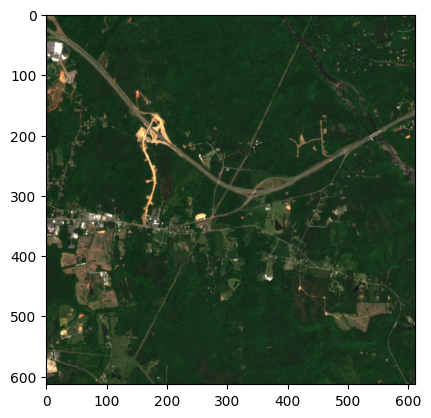

In [49]:
minx, miny, maxx, maxy = get_bounding_box(
    test_dates.iloc[0]["lat"], test_dates.iloc[0]["lon"], meter_buffer=3000
)

# get the zoomed in image array
bbox = (minx, miny, maxx, maxy)
zoomed_img_array = crop_sentinel_image(item, bbox)

zoomed_img_array[0]
plt.imshow(np.transpose(zoomed_img_array, axes=[1, 2, 0]))

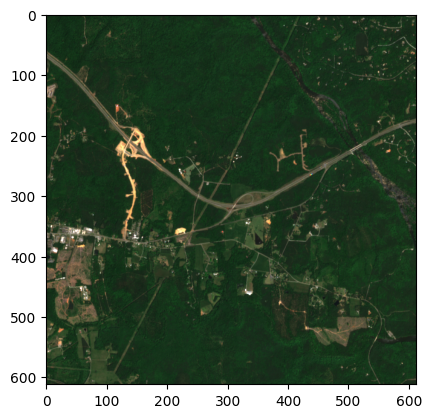

In [50]:
minx, miny, maxx, maxy = get_bounding_box(
    test_dates.iloc[1]["lat"], test_dates.iloc[1]["lon"], meter_buffer=3000
)

# get the zoomed in image array
bbox = (minx, miny, maxx, maxy)
zoomed_img_array = crop_sentinel_image(item, bbox)

zoomed_img_array[0]
plt.imshow(np.transpose(zoomed_img_array, axes=[1, 2, 0]))

In [51]:
print(test_dates.iloc[1]["lat"], test_dates.iloc[1]["lon"])

35.72433954 -79.12951135


In [52]:
test_dates

,uid,data_provider,region,lat,lon,date,time,year,month,day,abun,severity,distance_to_water_m,cyfi class,case,case_str,cluster_size
554,anrk,NC_Division_of_Water_Resources_NC_Department_o...,south,35.722290,-79.133318,2018-05-21,0:01:00,2018,5,21,0.145,1,1010.0,Low,449,449,117
567,dihj,NC_Division_of_Water_Resources_NC_Department_o...,south,35.724340,-79.129511,2018-05-21,0:01:00,2018,5,21,31.540,2,811.0,Moderate,449,449,117
571,dxqy,NC_Division_of_Water_Resources_NC_Department_o...,south,35.722264,-79.133367,2018-05-21,0:01:00,2018,5,21,0.290,1,1018.0,Low,449,449,117
574,edmh,NC_Division_of_Water_Resources_NC_Department_o...,south,35.722317,-79.133268,2018-05-21,0:01:00,2018,5,21,0.145,1,1010.0,Low,449,449,117
575,eetb,NC_Division_of_Water_Resources_NC_Department_o...,south,35.723275,-79.131489,2018-05-21,0:01:00,2018,5,21,3.389,1,885.0,Low,449,449,117
580,flph,NC_Division_of_Water_Resources_NC_Department_o...,south,35.724393,-79.129412,2018-05-21,0:01:00,2018,5,21,4.696,1,800.0,Low,449,449,117
584,guif,NC_Division_of_Water_Resources_NC_Department_o...,south,35.724419,-79.129363,2018-05-21,0:01:00,2018,5,21,60.420,2,807.0,Moderate,449,449,117
589,hknm,NC_Division_of_Water_Resources_NC_Department_o...,south,35.722210,-79.133466,2018-05-21,0:01:00,2018,5,21,1.017,1,1023.0,Low,449,449,117
590,htoo,NC_Division_of_Water_Resources_NC_Department_o...,south,35.723408,-79.131242,2018-05-21,0:01:00,2018,5,21,2.582,1,868.0,Low,449,449,117
596,jekg,NC_Division_of_Water_Resources_NC_Department_o...,south,35.724286,-79.129610,2018-05-21,0:01:00,2018,5,21,61.046,2,810.0,Moderate,449,449,117
